In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import logging
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

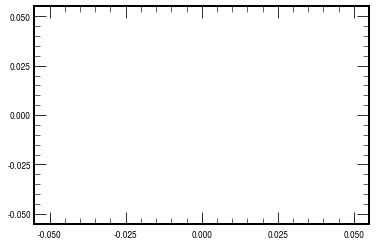

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
logging.getLogger().setLevel(logging.ERROR)

In [45]:
plots = plot_utils.loader(
    tag="full_analysis_Dec2025_2022_CR", era="2022", load_data=True
)

In [46]:
key = "QCD_Pt_MuEnrichedPt5_2022"
print(key)
print(plots[key]["CR_prompt"].values())
print(plots[key]["CR_prompt_LHEPdf1"].values())
print(plots[key]["CR_prompt_LHEPdf51"].values())
print(plots[key]["CR_prompt_LHEPdf100"].values())
print(plots[key]["CR_prompt_LHEPdf101"].values())
print(plots[key]["CR_prompt_LHEPdf102"].values())
print()

QCD_Pt_MuEnrichedPt5_2022

[0. 0. 0. 0.]

[0. 0. 0. 0.]

[0. 0. 0. 0.]

[0. 0. 0. 0.]

[0. 0. 0. 0.]

[0. 0. 0. 0.]

In [49]:
print([p for p in plots[key].keys() if "LHE" not in p and "CR_cb" in p])

[
    'CR_cb',
    'CR_cb_MuonSFUp',
    'CR_cb_MuonSFDown',
    'CR_cb_L1PreFireUp',
    'CR_cb_L1PreFireDown',
    'CR_cb_PUReweightUp',
    'CR_cb_PUReweightDown',
    'CR_cb_ISRUp',
    'CR_cb_ISRDown',
    'CR_cb_FSRUp',
    'CR_cb_FSRDown',
    'CR_cb_TrigSFUp',
    'CR_cb_TrigSFDown'
]

In [50]:
print(plots[key]["CR_cb"].values())
print(plots[key]["CR_cb_L1PreFireUp"].values())
print(plots[key]["CR_cb_L1PreFireDown"].values())

[1820104.55026595 1413666.27966257  477129.21982187   21087.19733913]

[0. 0. 0. 0.]

[0. 0. 0. 0.]

In [24]:
arr_central = plots["VV+VVV_2018"]["CR_cb"].values()
print(arr_central)
arr_sigma_replicas2 = np.zeros_like(arr_central)
for i in range(1, 101):
    arr_i = plots["VV+VVV_2018"][f"CR_cb_LHEPdf{i}"].values()
    arr_sigma_replicas2 = arr_sigma_replicas2 + (arr_i - arr_central) ** 2

print(np.sqrt(arr_sigma_replicas2))

arr_sigma_as = (
    abs(
        plots["VV+VVV_2018"][f"CR_cb_LHEPdf102"].values()
        - plots["VV+VVV_2018"][f"CR_cb_LHEPdf101"].values()
    )
    / 2
)

print(arr_sigma_as)

arr_sigma_pdf = np.sqrt(arr_sigma_as**2 + arr_sigma_replicas2)

print(arr_sigma_pdf)

[1546.53787491  101.09678486    6.43538494    0.30733272]

[59.21343257  4.48759336  0.33827618  0.00825363]

[       nan        nan 0.10090761 0.0015425 ]

[       nan        nan 0.35300584 0.00839653]

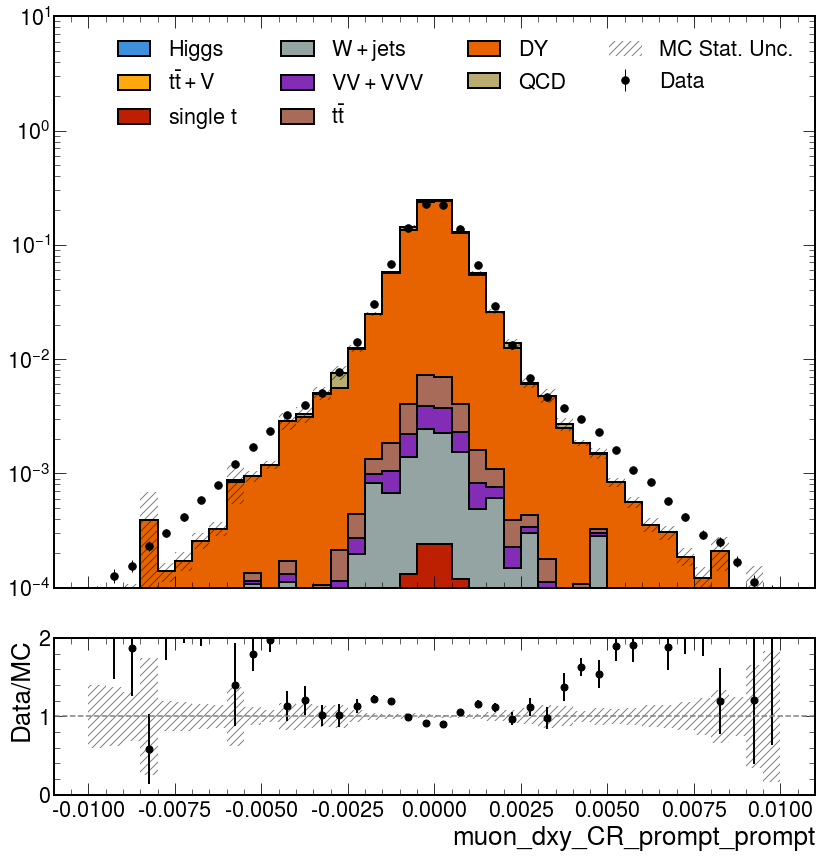

/tmp/ipykernel_646551/3227878374.py:11: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_646551/3227878374.py:11: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_646551/3227878374.py:12: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_646551/3227878374.py:12: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


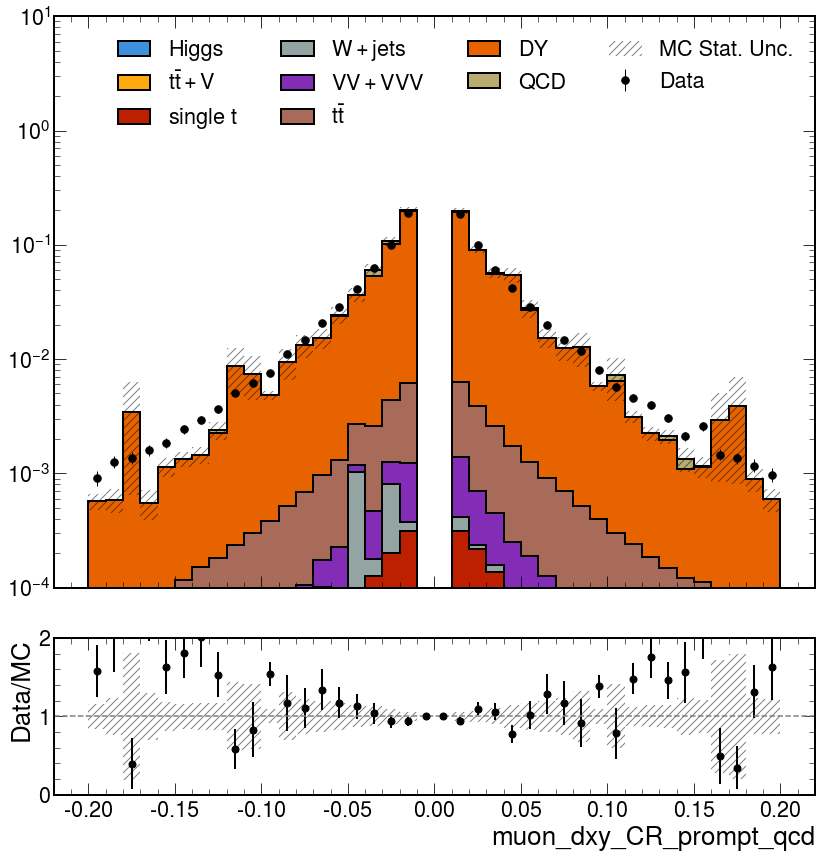

/tmp/ipykernel_646551/3227878374.py:11: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_646551/3227878374.py:11: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_646551/3227878374.py:12: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_646551/3227878374.py:12: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


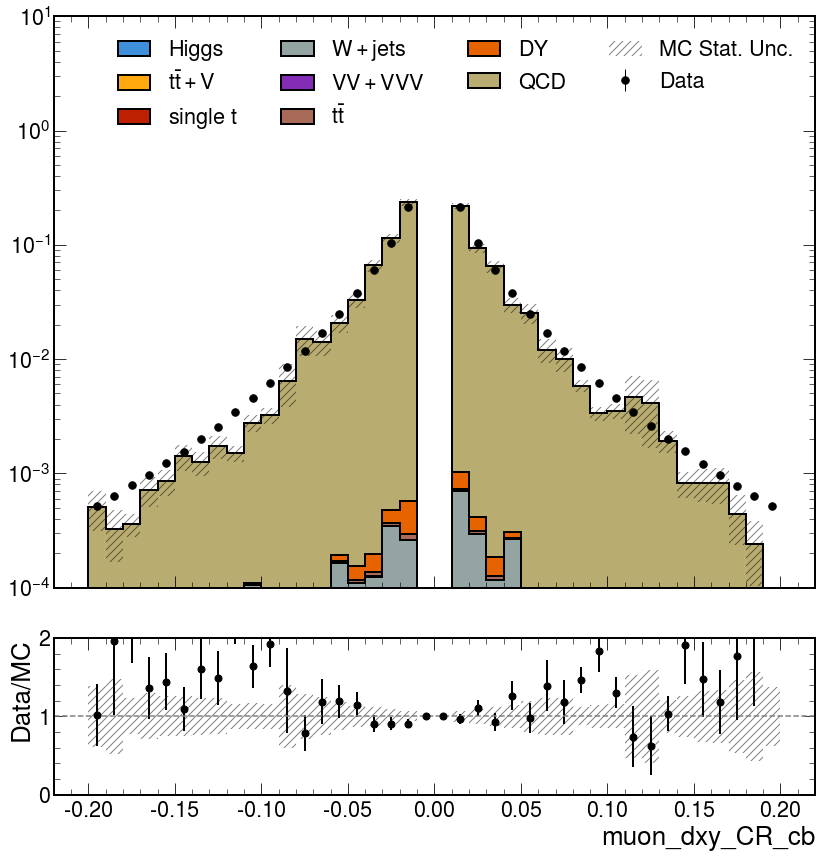

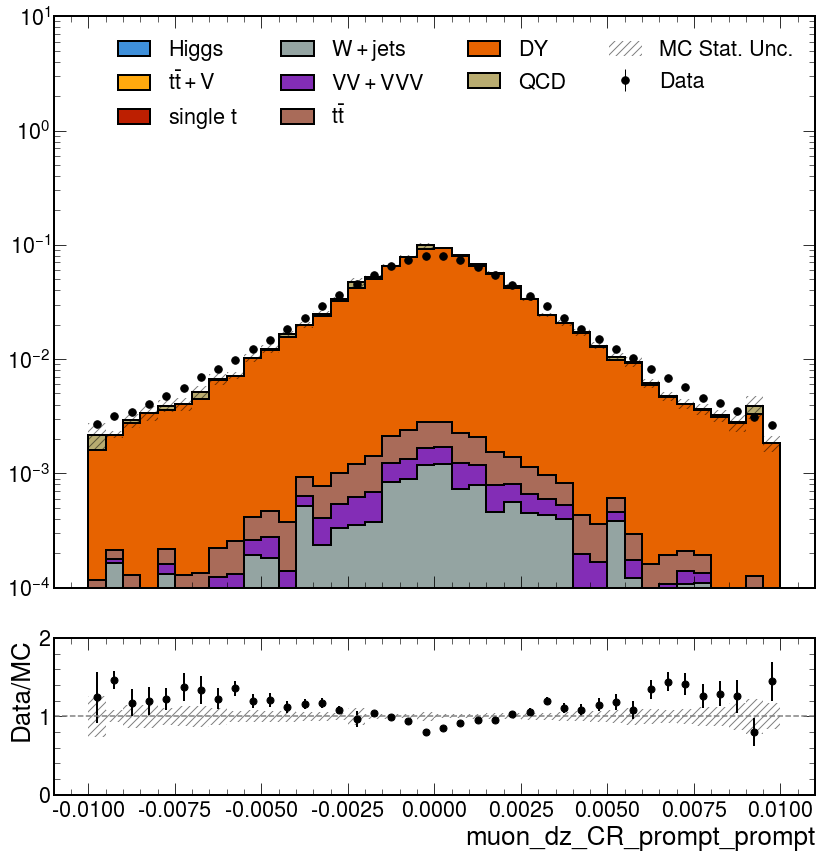

/tmp/ipykernel_646551/3227878374.py:11: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_646551/3227878374.py:11: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_646551/3227878374.py:12: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_646551/3227878374.py:12: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


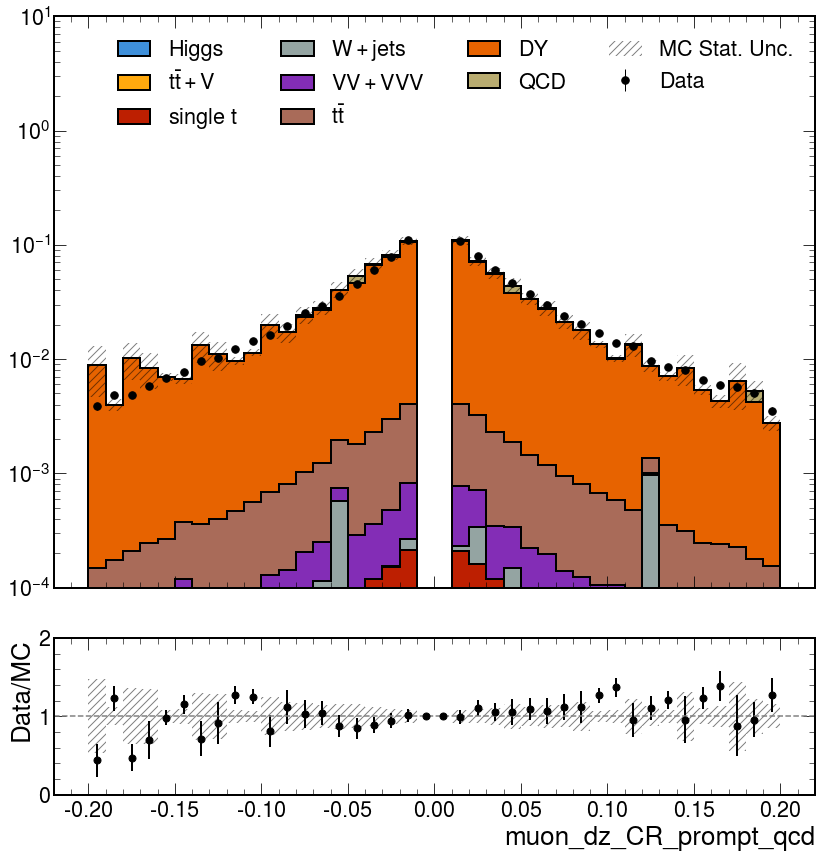

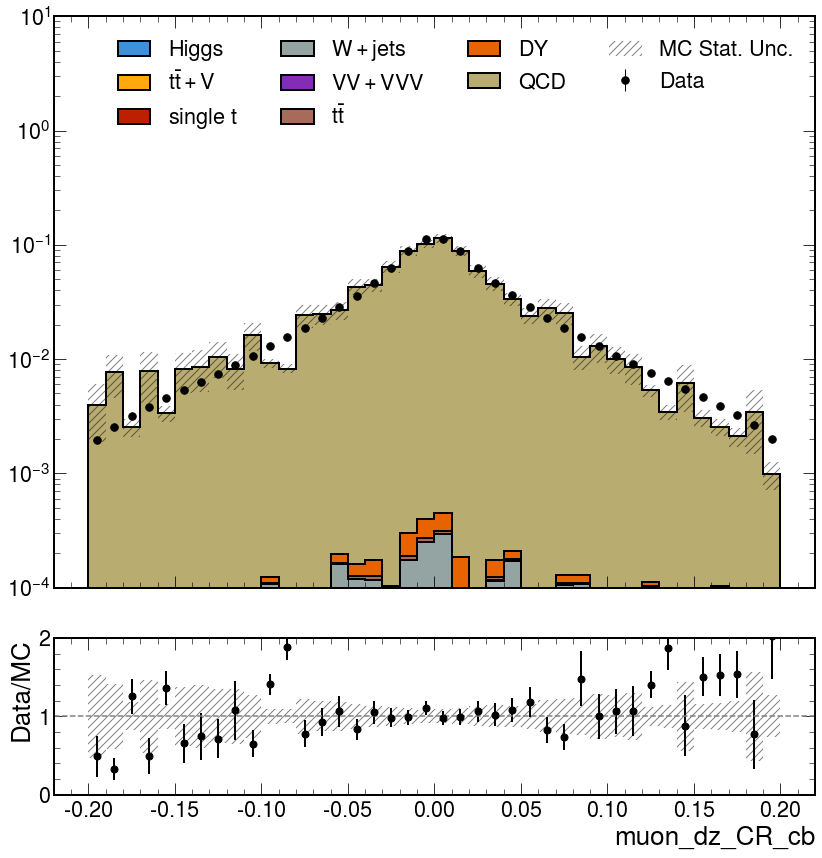

In [10]:
def plot_ratio(hist_data, hist_bkg_total, ax, x_hatch):
    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax.axhline(1, ls="--", color="gray")


mc_processes = [
    ("Higgs", "Higgs"),
    ("TTV", r"$t\bar{t}+V$"),
    ("ST_NLO", r"single $t$"),
    ("WJets", r"$W+jets$"),
    ("VV+VVV", r"$VV+VVV$"),
    ("TT_powheg", r"$t\bar{t}$"),
    ("DY", "DY"),
    ("QCD_Pt_MuEnrichedPt5", "QCD"),
]

for var in ["dxy", "dz"]:
    for region in ["CR_prompt_prompt", "CR_prompt_qcd", "CR_cb"]:
        plot = f"muon_{var}_{region}"
        hists_mc = []
        hist_bkg_total = plots[f"QCD_Pt_MuEnrichedPt5_2018"][plot][::1j].copy().reset()

        for process, label in mc_processes:
            h_mc = plots[f"{process}_2018"][plot][::1j]
            hists_mc.append(h_mc)
            hist_bkg_total += h_mc.copy()

        h_data = plots[f"Data_2018"][plot][::1j]
        h_data = h_data / h_data.sum().value

        for i in range(len(hists_mc)):
            hists_mc[i] = hists_mc[i] / hist_bkg_total.sum().value
        hist_bkg_total = hist_bkg_total / hist_bkg_total.sum().value

        fig = plt.figure(figsize=(12, 12.5))
        plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
        ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
        ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

        hep.histplot(
            hists_mc,
            yerr=[np.sqrt(h.variances()) for h in hists_mc],
            stack=True,
            label=[p[1] for p in mc_processes],
            histtype="fill",
            ec="black",
            lw=2,
            ax=ax1,
        )

        x_hatch = np.vstack(
            (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
        ).reshape((-1,), order="F")
        y_hatch1 = np.vstack(
            (hist_bkg_total.values(), hist_bkg_total.values())
        ).reshape((-1,), order="F")
        y_hatch1_unc = np.vstack(
            (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
        ).reshape((-1,), order="F")
        ax1.fill_between(
            x=x_hatch,
            y1=y_hatch1 - y_hatch1_unc,  # type: ignore[assign]
            y2=y_hatch1 + y_hatch1_unc,  # type: ignore[assign]
            label="MC Stat. Unc.",
            step="pre",
            facecolor="none",
            edgecolor=(0, 0, 0, 0.5),
            linewidth=0,
            hatch="///",
            zorder=2,
        )

        hep.histplot(
            h_data,
            label=["Data"],
            histtype="errorbar",
            mec="black",
            mfc="black",
            ecolor="black",
            markersize=15,
            lw=3,
            ax=ax1,
        )

        plot_ratio(h_data, hist_bkg_total, ax2, x_hatch)

        plt.sca(ax2)
        plt.xlabel(plot)
        plt.ylim(0, 2)
        plt.ylabel("Data/MC")
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_xlabel("", visible=False)

        plt.sca(ax1)
        plt.yscale("log")
        plt.ylim(1e-4, 10)
        plt.legend(ncol=4)
        plt.tight_layout()
        plt.show()

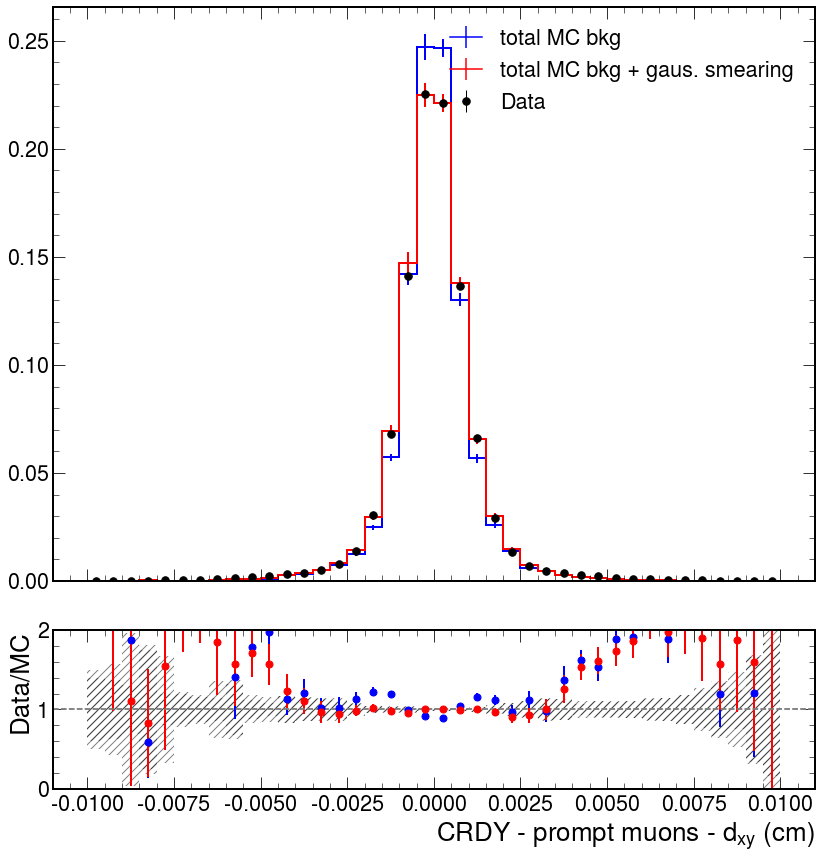

In [11]:
def smear(h_in, A=1, B=0.001):
    h_out = h_in.copy().reset()
    h_gaus = h_in.copy().reset()
    h_gaus.fill(
        A * np.random.normal(0, B, 10000) - h_in.axes.widths[0][0] / 2, weight=1
    )
    h_gaus = h_gaus / h_gaus.sum().value
    convolved_vals = np.convolve(h_in.values(), h_gaus.values(), mode="same")
    convolved_vars = np.convolve(h_in.variances(), h_gaus.values(), mode="same")
    for i, conv_val in enumerate(convolved_vals):
        h_out[i] = (conv_val, convolved_vars[i])
    return h_out


def plot_ratio(hist_data, hist_bkg_total, ax, x_hatch, color):
    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color=color,
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax.axhline(1, ls="--", color="gray")


mc_processes = [
    "Higgs",
    "TTV",
    "ST_NLO",
    "WJets",
    "VV+VVV",
    "TT_powheg",
    "DY",
    "QCD_Pt_MuEnrichedPt5",
]

plot = "muon_dxy_CR_prompt_prompt"
rebin = 1j
hist_bkg_total = plots[f"QCD_Pt_MuEnrichedPt5_2018"][plot][::rebin].copy().reset()

for process in mc_processes:
    h_mc = plots[f"{process}_2018"][plot][::rebin]
    hist_bkg_total += h_mc.copy()

hist_bkg_total = hist_bkg_total / hist_bkg_total.sum().value

h_data = plots[f"Data_2018"][plot][::rebin]
h_data = h_data / h_data.sum().value

fig = plt.figure(figsize=(12, 12.5))
plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

hep.histplot(
    hist_bkg_total,
    yerr=np.sqrt(hist_bkg_total.variances()),
    label="total MC bkg",
    color="blue",
    lw=2,
    ax=ax1,
)

h_smeared = smear(hist_bkg_total, 1, 0.0003)
# h_smeared = smear(h_smeared, 0.05, 0.005)
h_smeared = h_smeared / h_smeared.sum().value
hep.histplot(
    h_smeared,
    yerr=np.sqrt(h_smeared.variances()),
    label="total MC bkg + gaus. smearing",
    color="red",
    lw=2,
    ax=ax1,
)

x_hatch = np.vstack(
    (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
).reshape((-1,), order="F")
y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
    (-1,), order="F"
)
y_hatch1_unc = np.vstack(
    (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
).reshape((-1,), order="F")

hep.histplot(
    h_data,
    label="Data",
    histtype="errorbar",
    mec="black",
    mfc="black",
    ecolor="black",
    markersize=15,
    lw=3,
    ax=ax1,
)

plot_ratio(h_data, hist_bkg_total, ax2, x_hatch, "blue")

plot_ratio(h_data, h_smeared, ax2, x_hatch, "red")

plt.sca(ax2)
plt.xlabel(plot)
plt.ylim(0, 2)
plt.ylabel("Data/MC")
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.set_xlabel("", visible=False)
plt.xlabel("CRDY - prompt muons - $d_{xy}$ (cm)")

plt.sca(ax1)
# plt.yscale('log')
# plt.ylim(1e-5, 1)
plt.legend()
plt.tight_layout()
plt.show()

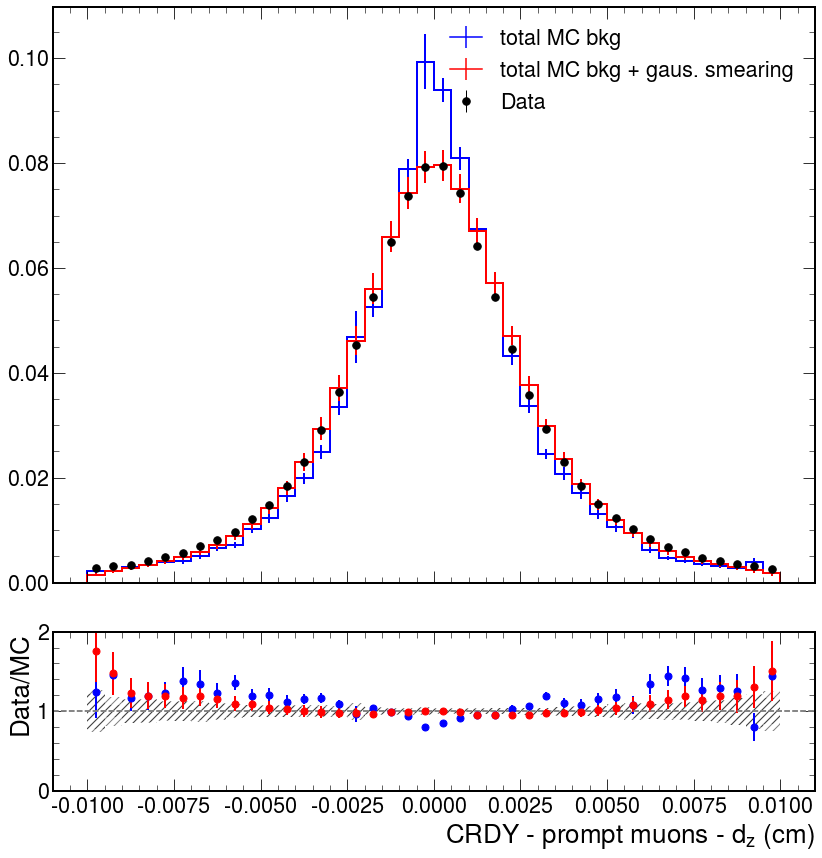

In [15]:
def smear(h_in, A=1, B=0.001):
    h_out = h_in.copy().reset()
    h_gaus = h_in.copy().reset()
    h_gaus.fill(
        A * np.random.normal(0, B, 10000) - h_in.axes.widths[0][0] / 2, weight=1
    )
    h_gaus = h_gaus / h_gaus.sum().value
    convolved_vals = np.convolve(h_in.values(), h_gaus.values(), mode="same")
    convolved_vars = np.convolve(h_in.variances(), h_gaus.values(), mode="same")
    for i, conv_val in enumerate(convolved_vals):
        h_out[i] = (conv_val, convolved_vars[i])
    return h_out


def plot_ratio(hist_data, hist_bkg_total, ax, x_hatch, color):
    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color=color,
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax.axhline(1, ls="--", color="gray")


mc_processes = [
    "Higgs",
    "TTV",
    "ST_NLO",
    "WJets",
    "VV+VVV",
    "TT_powheg",
    "DY",
    "QCD_Pt_MuEnrichedPt5",
]

plot = "muon_dz_CR_prompt_prompt"
rebin = 1j
hist_bkg_total = plots[f"QCD_Pt_MuEnrichedPt5_2018"][plot][::rebin].copy().reset()

for process in mc_processes:
    h_mc = plots[f"{process}_2018"][plot][::rebin]
    hist_bkg_total += h_mc.copy()

hist_bkg_total = hist_bkg_total / hist_bkg_total.sum().value

h_data = plots[f"Data_2018"][plot][::rebin]
h_data = h_data / h_data.sum().value

fig = plt.figure(figsize=(12, 12.5))
plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

hep.histplot(
    hist_bkg_total,
    yerr=np.sqrt(hist_bkg_total.variances()),
    label="total MC bkg",
    color="blue",
    lw=2,
    ax=ax1,
)

h_smeared = smear(hist_bkg_total, 1, 0.001)
# h_smeared = smear(h_smeared, 0.05, 0.005)
h_smeared = h_smeared / h_smeared.sum().value
hep.histplot(
    h_smeared,
    yerr=np.sqrt(h_smeared.variances()),
    label="total MC bkg + gaus. smearing",
    color="red",
    lw=2,
    ax=ax1,
)

x_hatch = np.vstack(
    (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
).reshape((-1,), order="F")
y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
    (-1,), order="F"
)
y_hatch1_unc = np.vstack(
    (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
).reshape((-1,), order="F")

hep.histplot(
    h_data,
    label="Data",
    histtype="errorbar",
    mec="black",
    mfc="black",
    ecolor="black",
    markersize=15,
    lw=3,
    ax=ax1,
)

plot_ratio(h_data, hist_bkg_total, ax2, x_hatch, "blue")

plot_ratio(h_data, h_smeared, ax2, x_hatch, "red")

plt.sca(ax2)
plt.xlabel(plot)
plt.ylim(0, 2)
plt.ylabel("Data/MC")
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.set_xlabel("", visible=False)
plt.xlabel("CRDY - prompt muons - $d_{z}$ (cm)")

plt.sca(ax1)
# plt.yscale('log')
# plt.ylim(1e-5, 1)
plt.legend()
plt.tight_layout()
plt.show()